In [1]:
import pymysql
import pandas as pd
from datetime import datetime, timedelta
from DATA.stock_invest_function import *

class USTradeExportExtractor:
    def __init__(self, host='localhost', user='root', password='your_password',
                 database='your_database', port=3306, charset='utf8mb4'):
        """데이터베이스 연결 초기화"""
        self.connection_params = {
            'host': host,
            'user': user,
            'password': password,
            'database': database,
            'port': port,
            'charset': charset
        }
        print(f"DB 연결 설정: {user}@{host}:{port}/{database}")

    def get_connection(self):
        """데이터베이스 연결 생성"""
        return pymysql.connect(**self.connection_params)

    def extract_by_date_string(self, target_date):
        """
        특정 날짜의 데이터 추출 (YYYY-MM-DD 형식)

        Parameters:
        target_date: str, 예: '2026-01-22'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) = %s
            ORDER BY hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[target_date])
            return df
        finally:
            conn.close()

    def extract_by_date_range(self, start_date, end_date):
        """
        날짜 범위의 데이터 추출

        Parameters:
        start_date: str, 예: '2026-01-20'
        end_date: str, 예: '2026-01-23'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) BETWEEN %s AND %s
            ORDER BY created_at, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[start_date, end_date])
            return df
        finally:
            conn.close()

    def extract_latest_data(self):
        """가장 최근 created_at 날짜의 데이터만 추출"""
        conn = self.get_connection()
        try:
            # 먼저 최신 날짜 찾기
            query_latest = """
            SELECT DATE(MAX(created_at)) as latest_date
            FROM us_trade_export_monthly_with_forecast
            """
            latest_date = pd.read_sql(query_latest, conn).iloc[0, 0]

            # 최신 날짜의 데이터 추출
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) = %s
            ORDER BY hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[latest_date])
            return df, latest_date
        finally:
            conn.close()

    def extract_by_datetime_range(self, start_datetime, end_datetime):
        """
        시간까지 포함한 정밀한 범위 추출

        Parameters:
        start_datetime: str, 예: '2026-01-22 17:00:00'
        end_datetime: str, 예: '2026-01-22 18:00:00'
        """
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE created_at BETWEEN %s AND %s
            ORDER BY created_at, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[start_datetime, end_datetime])
            return df
        finally:
            conn.close()

    def extract_recent_n_days(self, n_days=7):
        """최근 N일간의 데이터 추출"""
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE DATE(created_at) >= DATE_SUB(CURDATE(), INTERVAL %s DAY)
            ORDER BY created_at DESC, hs_code, date_month_end
            """
            df = pd.read_sql(query, conn, params=[n_days])
            return df
        finally:
            conn.close()

    def get_distinct_created_dates(self):
        """저장된 모든 고유 날짜 목록 조회"""
        conn = self.get_connection()
        try:
            query = """
            SELECT DISTINCT DATE(created_at) as created_date,
                   COUNT(*) as record_count
            FROM us_trade_export_monthly_with_forecast
            GROUP BY DATE(created_at)
            ORDER BY created_date DESC
            """
            df = pd.read_sql(query, conn)
            return df
        finally:
            conn.close()

    def extract_by_hs_code_and_date(self, hs_code, target_date):
        """특정 HS 코드와 날짜의 데이터 추출"""
        conn = self.get_connection()
        try:
            query = """
            SELECT *
            FROM us_trade_export_monthly_with_forecast
            WHERE hs_code = %s AND DATE(created_at) = %s
            ORDER BY date_month_end
            """
            df = pd.read_sql(query, conn, params=[hs_code, target_date])
            return df
        finally:
            conn.close()

    def get_all_hs_codes(self, target_date=None):
        """특정 날짜(또는 최신)의 모든 HS 코드 목록 조회"""
        conn = self.get_connection()
        try:
            if target_date:
                query = """
                SELECT DISTINCT hs_code
                FROM us_trade_export_monthly_with_forecast
                WHERE DATE(created_at) = %s
                ORDER BY hs_code
                """
                df = pd.read_sql(query, conn, params=[target_date])
            else:
                query = """
                SELECT DISTINCT hs_code
                FROM us_trade_export_monthly_with_forecast
                WHERE DATE(created_at) = (
                    SELECT DATE(MAX(created_at))
                    FROM us_trade_export_monthly_with_forecast
                )
                ORDER BY hs_code
                """
                df = pd.read_sql(query, conn)
            return df['hs_code'].tolist()
        finally:
            conn.close()




In [2]:
# 사용 예시

# db_info = {
#     'user': 'stox7412',         # 예: 'root'
#     'password': 'Apt106503!~', # 예: '1234'
#     # 'host' : '192.168.0.230',
#     'host': get_db_host(),         # 예: 'localhost' 또는 IP
#     'port': 3307,              # 기본 포트는 보통 3306
#     'database': 'investar'        # 예: 'trade_data'
# }


extractor = USTradeExportExtractor(
    host=get_db_host(),
    user='stox7412',
    password='Apt106503!~',
    database='investar',
    port=3307
)

# 1. 특정 날짜 데이터 추출
print("=== 특정 날짜 데이터 추출 ===")
df_today = extractor.extract_by_date_string('2026-01-22')
print(f"추출된 레코드 수: {len(df_today)}")
print(df_today.tail())

# # 2. 가장 최근 데이터 추출
# print("\n=== 최신 데이터 추출 ===")
# df_latest, latest_date = extractor.extract_latest_data()
# print(f"최신 날짜: {latest_date}")
# print(f"추출된 레코드 수: {len(df_latest)}")
#
# # 3. 날짜 범위로 추출
# print("\n=== 날짜 범위 데이터 추출 ===")
# df_range = extractor.extract_by_date_range('2026-01-20', '2026-01-23')
# print(f"추출된 레코드 수: {len(df_range)}")
#
# # 4. 최근 7일 데이터
# print("\n=== 최근 7일 데이터 ===")
# df_week = extractor.extract_recent_n_days(7)
# print(f"추출된 레코드 수: {len(df_week)}")
#
# # 5. 저장된 날짜 목록 확인
# print("\n=== 저장된 날짜 목록 ===")
# dates_df = extractor.get_distinct_created_dates()
# print(dates_df)
#
# # 6. 특정 HS 코드와 날짜로 추출
# print("\n=== 특정 HS 코드 데이터 ===")
# df_hs = extractor.extract_by_hs_code_and_date('100199', '2026-01-22')
# print(f"추출된 레코드 수: {len(df_hs)}")

# 7. CSV로 저장
# df_latest.to_csv('latest_export_forecast.csv', index=False, encoding='utf-8-sig')
# print("\n최신 데이터를 CSV로 저장했습니다.")

DB 연결 설정: stox7412@192.168.0.230:3307/investar
=== 특정 날짜 데이터 추출 ===
추출된 레코드 수: 78076
      hs_code date_month_end  expDlr  expDlr_forecast  is_forecast  \
78071  988000     2026-12-31     NaN     6.380452e+09            1   
78072  988000     2027-01-31     NaN     5.126828e+09            1   
78073  988000     2027-02-28     NaN     5.556517e+09            1   
78074  988000     2027-03-31     NaN     5.646205e+09            1   
78075  988000     2027-04-30     NaN     5.937489e+09            1   

                                                  params          created_at  
78071  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
78072  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
78073  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
78074  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  
78075  {"model": "SARIMA", "order": [0, 1, 2], "seaso... 2026-01-22 17:48:20  


In [3]:
len(df_today['hs_code'].unique())

478

In [7]:
df_today[df_today['hs_code'] == '854231'].tail(24)

,hs_code,date_month_end,expDlr,expDlr_forecast,is_forecast,params,created_at
58619,854231,2025-05-31,2.816068e+09,2.816068e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58620,854231,2025-06-30,2.743521e+09,2.743521e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58621,854231,2025-07-31,2.901765e+09,2.901765e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58622,854231,2025-08-31,2.804615e+09,2.804615e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58623,854231,2025-09-30,2.643287e+09,2.643287e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58624,854231,2025-10-31,2.982020e+09,2.982020e+09,0,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58625,854231,2025-11-30,NaN,2.839274e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58626,854231,2025-12-31,NaN,2.779283e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58627,854231,2026-01-31,NaN,2.953091e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20
58628,854231,2026-02-28,NaN,2.564394e+09,1,"{""model"": ""SARIMA"", ""order"": [0, 1, 2], ""seaso...",2026-01-22 17:48:20


<AxesSubplot: >

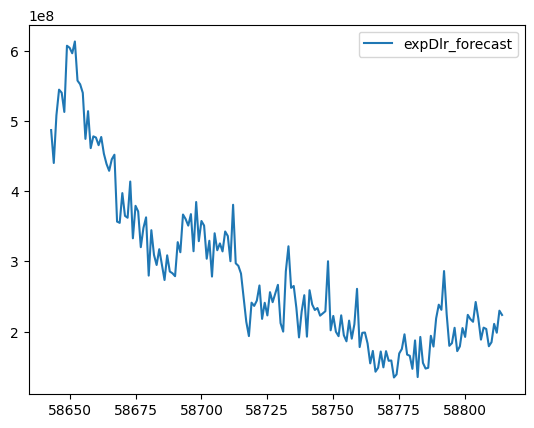

In [5]:
df_today[df_today['hs_code'] == '854232'][['expDlr_forecast']].plot()

#### 2. 향후 12개월 수출 증가율이 높은 아이템 추출

In [6]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text


def _detect_version_col(conn, table):
    """테이블에 created_at / input_date 중 어떤 버전 컬럼이 있는지 감지."""
    res = conn.execute(text(f"SHOW COLUMNS FROM {table}"))
    cols = [r[0] for r in res.fetchall()]
    for c in ("created_at", "input_date"):
        if c in cols:
            return c
    return None


def calculate_export_growth_ranking(db_info, past_date, future_date,
                                     save_path=None, sanity_ratio=1000.0):
    """
    과거 12개월 대비 미래 12개월 수출액 증가율 랭킹 (전체 HS Code).

    ★ 수정 핵심 (단위/값 왜곡 차단):
      - HS별 '최신 버전(created_at/input_date)' 행만 사용
        → 과거 폭발 run(V3/V4)·중복 run 혼입으로 인한 합계/증가율 왜곡 제거
      - recent_12month<=0 → growth=NaN + flag (가짜 100% 제거)
      - 폭발/음수 합계 → flag 로 분리 (값은 보존, 랭킹 하단 배치)
      - 전체 HS Code 를 growth_rate 내림차순으로 CSV 저장

    growth_rate 단위: 퍼센트(%). 예) 6.45 = +6.45%

    Returns: pd.DataFrame (전체 HS Code 랭킹)
    """
    TABLE = "us_trade_export_monthly_with_forecast"

    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info.get('port', 3306)}/{db_info['database']}"
    )

    past_dt   = pd.to_datetime(past_date)
    future_dt = pd.to_datetime(future_date)
    past_start, past_end     = past_dt - pd.DateOffset(months=11), past_dt
    future_start, future_end = future_dt, future_dt + pd.DateOffset(months=11)

    print("=" * 80)
    print("수출 성장률 분석 (전체 HS Code)")
    print("=" * 80)
    print(f"  과거 12개월: {past_start:%Y-%m-%d} ~ {past_end:%Y-%m-%d}")
    print(f"  미래 12개월: {future_start:%Y-%m-%d} ~ {future_end:%Y-%m-%d}")

    # ── 1. 버전 컬럼 감지 후 'HS별 최신 버전'만 로드 ──
    with engine.connect() as conn:
        vcol = _detect_version_col(conn, TABLE)

        if vcol:
            sql = f"""
                SELECT t.hs_code, t.date_month_end, t.expDlr,
                       t.expDlr_forecast, t.is_forecast
                FROM {TABLE} t
                JOIN (
                    SELECT hs_code, MAX({vcol}) AS mx
                    FROM {TABLE}
                    GROUP BY hs_code
                ) l ON t.hs_code = l.hs_code AND t.{vcol} = l.mx
                ORDER BY t.hs_code, t.date_month_end
            """
            print(f"\n[버전 관리] '{vcol}' 기준 HS별 최신 run 만 사용 (과거 폭발 run 제외)")
        else:
            sql = f"""
                SELECT hs_code, date_month_end, expDlr,
                       expDlr_forecast, is_forecast
                FROM {TABLE}
                ORDER BY hs_code, date_month_end
            """
            print("\n[주의] 버전 컬럼(created_at/input_date) 없음 → 전체 행 사용")

        print("데이터 로딩 중...")
        res  = conn.execute(text(sql))
        rows = res.fetchall()
        cols = list(res.keys())

    df = pd.DataFrame(rows, columns=cols)
    df["date_month_end"] = pd.to_datetime(df["date_month_end"])
    print(f"  로드 레코드: {len(df):,} / HS 코드: {df['hs_code'].nunique():,}")

    # ── 2. 실측/예측 통합 값 ──
    df["export_value"] = np.where(df["is_forecast"] == 1,
                                  df["expDlr_forecast"], df["expDlr"])

    # ── 3. 과거/미래 12개월 합계 ──
    past_mask   = (df["date_month_end"] >= past_start)   & (df["date_month_end"] <= past_end)
    future_mask = (df["date_month_end"] >= future_start) & (df["date_month_end"] <= future_end)

    past_sum   = (df[past_mask].groupby("hs_code")["export_value"].sum()
                  .rename("recent_12month"))
    future_sum = (df[future_mask].groupby("hs_code")["export_value"].sum()
                  .rename("future_12month"))

    # outer 병합 → 전체 HS Code 보존 (한쪽 윈도우만 있는 코드도 포함)
    result = pd.concat([past_sum, future_sum], axis=1).reset_index()

    # ── 4. 성장률 + 위생 플래그 ──
    rec = result["recent_12month"]
    fut = result["future_12month"]

    result["growth_rate"] = np.where(
        rec > 0, (fut / rec - 1.0) * 100.0, np.nan
    )

    def _flag(row):
        r, f = row["recent_12month"], row["future_12month"]
        if pd.isna(r) or pd.isna(f):       return "missing_window"
        if r <= 0:                          return "recent<=0"
        if f < 0:                           return "negative_forecast"
        if f > r * sanity_ratio:            return "explosive"
        return None
    result["flag"] = result.apply(_flag, axis=1)

    # ── 5. 정렬: 정상(flag 없음) growth 내림차순 먼저, 이상치는 하단 ──
    result["_is_clean"] = result["flag"].isna()
    result = (result
              .sort_values(["_is_clean", "growth_rate"],
                           ascending=[False, False],
                           na_position="last")
              .drop(columns="_is_clean")
              .reset_index(drop=True))

    result.insert(0, "past_date", past_date)
    result.insert(1, "future_date", future_date)
    result.insert(0, "rank", range(1, len(result) + 1))

    n_clean = int(result["flag"].isna().sum())
    print("\n" + "=" * 80)
    print(f"전체 {len(result):,}개 HS Code 분석 완료 "
          f"(정상 {n_clean:,} / 이상 {len(result) - n_clean:,})")
    if (result["flag"].notna()).any():
        print("  [이상 플래그 분포]")
        for k, v in result["flag"].value_counts().items():
            print(f"    - {k:<18}: {v:,}")

    clean = result[result["flag"].isna()]
    print("\n[상위 10 (정상) — 단위: %]")
    prev = clean.head(10)[["rank", "hs_code",
                           "recent_12month", "future_12month", "growth_rate"]].copy()
    with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
        print(prev.to_string(index=False))
    if n_clean:
        print(f"\n[정상 성장률 통계] 평균 {clean['growth_rate'].mean():.2f}% / "
              f"중앙값 {clean['growth_rate'].median():.2f}% / "
              f"최대 {clean['growth_rate'].max():.2f}% / "
              f"최소 {clean['growth_rate'].min():.2f}%")

    # ── 6. CSV 저장 (전체 HS Code) ──
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        ps, fsx = past_date.replace("-", ""), future_date.replace("-", "")
        full_fp  = os.path.join(save_path, f"export_growth_ranking_{ps}_to_{fsx}.csv")
        clean_fp = os.path.join(save_path, f"export_growth_ranking_{ps}_to_{fsx}_clean.csv")
        out_cols = ["rank", "past_date", "future_date", "hs_code",
                    "recent_12month", "future_12month", "growth_rate", "flag"]
        result[out_cols].to_csv(full_fp, index=False, encoding="utf-8-sig")
        clean[out_cols].to_csv(clean_fp, index=False, encoding="utf-8-sig")
        print(f"\n[저장] 전체 랭킹 : {full_fp}  ({len(result):,} rows)")
        print(f"[저장] 정상 only : {clean_fp}  ({n_clean:,} rows)")

    engine.dispose()
    return result


In [7]:
# 2. DB 및 객체 초기화
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

# 저장 경로 지정
save_path = r"C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\US_Export_growth"

# 함수 호출
ranking_df = calculate_export_growth_ranking(
    db_info=db_info,
    past_date='2026-03-31',
    future_date='2026-04-30',
    save_path=save_path  # 저장 경로 전달
)

# 결과를 CSV 파일로 저장 (선택사항)
# output_filename = f"export_growth_ranking_{past_date}_to_{future_date}.csv"
# ranking_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
# print(f"\n💾 결과가 '{output_filename}' 파일로 저장되었습니다.")

# 상위 20개만 별도로 확인
print("\n" + "=" * 80)
print("TOP 20 성장률 HS 코드")
print("=" * 80)
print(ranking_df.head(20).to_string(index=False))

수출 성장률 분석 (전체 HS Code)
  과거 12개월: 2025-04-30 ~ 2026-03-31
  미래 12개월: 2026-04-30 ~ 2027-03-30

[버전 관리] 'created_at' 기준 HS별 최신 run 만 사용 (과거 폭발 run 제외)
데이터 로딩 중...
  로드 레코드: 68,320 / HS 코드: 500

전체 498개 HS Code 분석 완료 (정상 498 / 이상 0)

[상위 10 (정상) — 단위: %]
 rank hs_code    recent_12month     future_12month  growth_rate
    1  854159  2,945,961,357.00   8,201,559,035.34       178.40
    2  711291  4,080,849,462.00   9,793,330,403.77       139.98
    3  270900 98,957,202,799.00 197,217,217,764.00        99.30
    4  870451    953,833,976.00   1,832,814,708.89        92.15
    5  847150 38,833,414,609.00  70,907,792,307.29        82.59
    6  711011  2,709,372,639.00   4,938,122,181.94        82.26
    7  271019 66,415,238,480.00 109,642,566,248.26        65.09
    8  852351 10,727,379,910.00  17,535,577,138.60        63.47
    9  120190 17,694,470,690.00  28,245,301,890.02        59.63
   10  847330 42,754,550,789.00  67,819,167,947.70        58.62

[정상 성장률 통계] 평균 -3.74% / 중앙값 -6.32% / 최대 178

In [15]:
ranking_df[ranking_df['hs_code'] == '852351']

,rank,past_date,future_date,hs_code,recent_12month,future_12month,growth_rate,flag
7,8,2026-03-31,2026-04-30,852351,1.072738e+10,1.753558e+10,63.465611,None


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [11]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

def visualize_export_forecast(db_info, hs_code, past_date='2014-01-31',
                              future_months=12, figsize=(14, 7),
                              forecast_date_col='forecast_date'):
    """
    HS 코드별 수출 실적 및 예측 시각화
    - (hs_code, date_month_end)별로 가장 최근 forecast run만 사용
    """

    # ============================================================
    # 1. (hs_code, date_month_end)별 최근 run만 선택
    #    MySQL 8.0+ 윈도우 함수 사용
    # ============================================================
    query = f"""
    SELECT hs_code, date_month_end, expDlr, expDlr_forecast, is_forecast
    FROM (
        SELECT
            hs_code,
            date_month_end,
            expDlr,
            expDlr_forecast,
            is_forecast,
            ROW_NUMBER() OVER (
                PARTITION BY hs_code, date_month_end
                ORDER BY {forecast_date_col} DESC
            ) AS rn
        FROM us_trade_export_monthly_with_forecast
        WHERE hs_code = %s
    ) t
    WHERE rn = 1
    ORDER BY date_month_end
    """

    print(f"📊 HS Code {hs_code} 데이터 조회 중...")

    # pd.read_sql 미사용, cursor 패턴
    conn = pymysql.connect(**db_info)
    try:
        with conn.cursor() as cursor:
            cursor.execute(query, (hs_code,))
            rows = cursor.fetchall()
            cols = [d[0] for d in cursor.description]
    finally:
        conn.close()

    df = pd.DataFrame(rows, columns=cols)

    if df.empty:
        print(f"❌ HS Code {hs_code}에 대한 데이터가 없습니다.")
        return None, None, None

    # ============================================================
    # 2. 중복 진단 (혹시 위 쿼리 후에도 중복 있으면 즉시 알람)
    # ============================================================
    dup_cnt = df.duplicated(subset=['hs_code', 'date_month_end']).sum()
    if dup_cnt > 0:
        print(f"⚠️ 중복 row 감지: {dup_cnt}개 — forecast_date_col 인자 확인 필요")

    # 날짜 변환
    df['date_month_end'] = pd.to_datetime(df['date_month_end'])
    past_dt = pd.to_datetime(past_date)

    # 수출액 통합 (실적 우선, 없으면 예측값)
    df['export_value'] = df.apply(
        lambda x: x['expDlr'] if pd.notna(x['expDlr']) and x['expDlr'] > 0
        else x['expDlr_forecast'],
        axis=1
    )

    # 실적/예측 분리
    actual_df = df[df['date_month_end'] <= past_dt].copy()
    forecast_df = df[df['date_month_end'] > past_dt].copy()

    print(f"✓ 실적 데이터: {len(actual_df)}개")
    print(f"✓ 예측 데이터: {len(forecast_df)}개")

    # 성장률 계산
    growth_rate = None
    if len(forecast_df) >= future_months:
        past_12m_start = past_dt - pd.DateOffset(months=11)
        past_12m_df = df[
            (df['date_month_end'] >= past_12m_start) &
            (df['date_month_end'] <= past_dt)
        ]
        past_12m_sum = past_12m_df['export_value'].sum()
        future_12m_sum = forecast_df.head(future_months)['export_value'].sum()

        if past_12m_sum > 0:
            growth_rate = ((future_12m_sum - past_12m_sum) / past_12m_sum) * 100

        print(f"\n📈 성장률 분석:")
        print(f"  과거 12개월 합계: ${past_12m_sum:,.0f}")
        print(f"  향후 12개월 예측: ${future_12m_sum:,.0f}")
        print(f"  성장률: {growth_rate:+.2f}%")

    # ============================================================
    # 3. 시각화 (기존 로직 유지)
    # ============================================================
    fig, ax = plt.subplots(figsize=figsize)

    if not actual_df.empty:
        ax.plot(actual_df['date_month_end'], actual_df['export_value'],
                color='#2E86AB', linewidth=2.5, marker='o', markersize=4,
                label='실적 (Actual)', zorder=3)

    if not forecast_df.empty:
        if not actual_df.empty:
            last_actual = actual_df.iloc[-1]
            forecast_plot_df = pd.concat([
                pd.DataFrame([{
                    'date_month_end': last_actual['date_month_end'],
                    'export_value': last_actual['export_value']
                }]),
                forecast_df
            ], ignore_index=True)
        else:
            forecast_plot_df = forecast_df

        forecast_label = (f'예측 (Forecast) - 향후 12개월 성장률: {growth_rate:+.2f}%'
                          if growth_rate is not None else '예측 (Forecast)')

        ax.plot(forecast_plot_df['date_month_end'], forecast_plot_df['export_value'],
                color='#A23B72', linewidth=2.5, linestyle='--',
                marker='s', markersize=4, label=forecast_label, zorder=3)

    ax.axvline(x=past_dt, color='gray', linestyle=':', linewidth=1.5,
               alpha=0.7, label=f'기준일: {past_date}')

    ax.set_xlabel('날짜', fontsize=12, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12, fontweight='bold')
    ax.set_title(f'HS Code {hs_code} - 수출 실적 및 예측',
                 fontsize=16, fontweight='bold', pad=20)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    plt.tight_layout()

    print(f"\n✓ 시각화 완료")
    return fig, ax, growth_rate


def visualize_multiple_hs_codes(db_info, hs_codes, past_date='2014-01-31',
                                future_months=12, figsize=(14, 8)):
    """
    여러 HS 코드를 한 그래프에 표시

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
    hs_codes : list
        조회할 HS 코드 리스트
    past_date : str
        실적과 예측의 구분 기준일
    future_months : int
        향후 예측 개월 수
    figsize : tuple
        그래프 크기

    Returns:
    --------
    tuple
        (fig, ax, growth_rates_dict) - 그래프 객체와 성장률 딕셔너리
    """

    # SQLAlchemy 엔진 생성
    engine = create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
        f"{db_info['host']}:{db_info.get('port', 3306)}/{db_info['database']}"
    )

    # 색상 팔레트
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E',
              '#BC4B51', '#5B8E7D', '#8B5A3C', '#4A5859', '#C9ADA7']

    fig, ax = plt.subplots(figsize=figsize)
    past_dt = pd.to_datetime(past_date)
    growth_rates = {}

    for idx, hs_code in enumerate(hs_codes):
        color = colors[idx % len(colors)]

        # 데이터 조회
        query = f"""
        SELECT
            hs_code,
            date_month_end,
            expDlr,
            expDlr_forecast,
            is_forecast
        FROM investarus_trade_export_monthly_with_forecast
        WHERE hs_code = '{hs_code}'
        ORDER BY date_month_end
        """

        df = pd.read_sql(query, engine)

        if df.empty:
            print(f"⚠️ HS Code {hs_code}: 데이터 없음")
            continue

        df['date_month_end'] = pd.to_datetime(df['date_month_end'])
        df['export_value'] = df.apply(
            lambda x: x['expDlr'] if pd.notna(x['expDlr']) and x['expDlr'] > 0
            else x['expDlr_forecast'],
            axis=1
        )

        # 실적과 예측 분리
        actual_df = df[df['date_month_end'] <= past_dt].copy()
        forecast_df = df[df['date_month_end'] > past_dt].copy()

        # 성장률 계산
        if len(forecast_df) >= future_months:
            past_12m_start = past_dt - pd.DateOffset(months=11)
            past_12m_df = df[
                (df['date_month_end'] >= past_12m_start) &
                (df['date_month_end'] <= past_dt)
            ]
            past_12m_sum = past_12m_df['export_value'].sum()
            future_12m_sum = forecast_df.head(future_months)['export_value'].sum()

            if past_12m_sum > 0:
                growth_rate = ((future_12m_sum - past_12m_sum) / past_12m_sum) * 100
            else:
                growth_rate = 0.0

            growth_rates[hs_code] = growth_rate
        else:
            growth_rates[hs_code] = None

        # 실적 플롯
        if not actual_df.empty:
            ax.plot(actual_df['date_month_end'],
                   actual_df['export_value'],
                   color=color,
                   linewidth=2,
                   marker='o',
                   markersize=3,
                   label=f'{hs_code} (실적)')

        # 예측 플롯
        if not forecast_df.empty:
            if not actual_df.empty:
                last_actual = actual_df.iloc[-1]
                forecast_plot_df = pd.concat([
                    pd.DataFrame([{
                        'date_month_end': last_actual['date_month_end'],
                        'export_value': last_actual['export_value']
                    }]),
                    forecast_df
                ], ignore_index=True)
            else:
                forecast_plot_df = forecast_df

            growth_label = f' ({growth_rates[hs_code]:+.1f}%)' if growth_rates[hs_code] is not None else ''

            ax.plot(forecast_plot_df['date_month_end'],
                   forecast_plot_df['export_value'],
                   color=color,
                   linewidth=2,
                   linestyle='--',
                   marker='s',
                   markersize=3,
                   label=f'{hs_code} (예측{growth_label})')

    engine.dispose()

    # 구분선
    ax.axvline(x=past_dt, color='gray', linestyle=':', linewidth=1.5,
               alpha=0.7, label=f'기준일: {past_date}')

    # 그래프 스타일링
    ax.set_xlabel('날짜', fontsize=12, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12, fontweight='bold')
    ax.set_title('HS Code별 수출 실적 및 예측 비교',
                fontsize=16, fontweight='bold', pad=20)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)

    plt.tight_layout()

    return fig, ax, growth_rates


# 사용 예시
# if __name__ == "__main__":
#     # 데이터베이스 연결 정보
#     db_info = {
#         'host': 'localhost',
#         'user': 'your_username',
#         'password': 'your_password',
#         'database': 'your_database',
#         'port': 3306
#     }
#
#     # 단일 HS 코드 시각화
#     print("=" * 80)
#     print("단일 HS Code 시각화")
#     print("=" * 80)
#
#     hs_code = '100199'
#     fig1, ax1, growth_rate = visualize_export_forecast(
#         db_info=db_info,
#         hs_code=hs_code,
#         past_date='2014-01-31',
#         future_months=12,
#         figsize=(14, 7)
#     )
#
#     if fig1:
#         plt.show()
#         # 또는 저장
#         # fig1.savefig(f'export_forecast_{hs_code}.png', dpi=300, bbox_inches='tight')
#
#     # 여러 HS 코드 비교 시각화
#     print("\n" + "=" * 80)
#     print("여러 HS Code 비교 시각화")
#     print("=" * 80)
#
#     hs_codes = ['100199', '100190', '100630']
#     fig2, ax2, growth_rates = visualize_multiple_hs_codes(
#         db_info=db_info,
#         hs_codes=hs_codes,
#         past_date='2014-01-31',
#         future_months=12,
#         figsize=(14, 8)
#     )
#
#     print("\n📊 성장률 요약:")
#     for hs, rate in growth_rates.items():
#         if rate is not None:
#             print(f"  HS {hs}: {rate:+.2f}%")
#         else:
#             print(f"  HS {hs}: 데이터 부족")
#
#     plt.show()

📊 HS Code 340242 데이터 조회 중...
✓ 실적 데이터: 51개
✓ 예측 데이터: 19개

📈 성장률 분석:
  과거 12개월 합계: $771,767,880
  향후 12개월 예측: $790,941,495
  성장률: +2.48%

✓ 시각화 완료


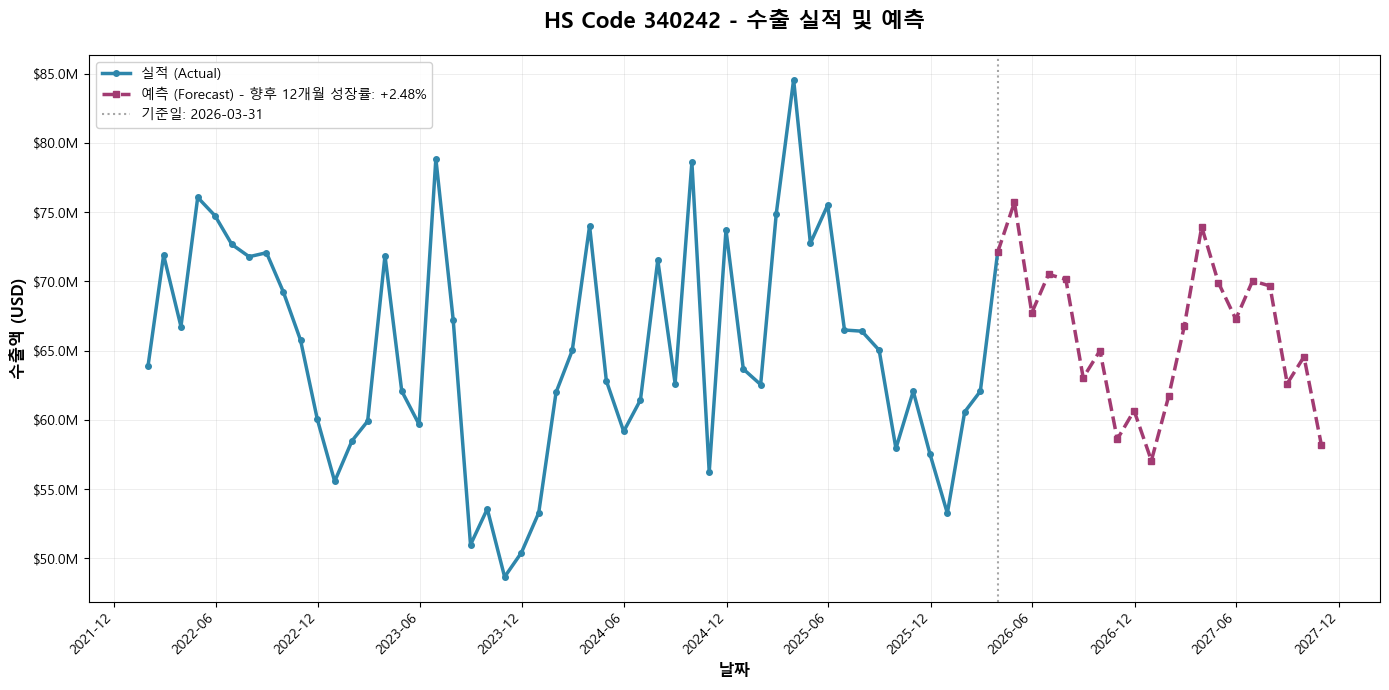

In [12]:
fig, ax, growth_rate = visualize_export_forecast(
    db_info=db_info,
    hs_code='340242',
    past_date='2026-03-31',
    future_months=12,
    forecast_date_col='created_at'
)

# # 여러 HS 코드 비교
# hs_codes = ['100199', '100190', '100630']
# fig, ax, growth_rates = visualize_multiple_hs_codes(
#     db_info=db_info,
#     hs_codes=hs_codes,
#     past_date='2014-01-31'
# )
# plt.show()

In [13]:
import pymysql
import pandas as pd

conn = pymysql.connect(**db_info)
try:
    with conn.cursor() as cursor:

        # ───── 진단 1: params 값 분포 (어떤 모델들이 저장되어 있나)
        print("=" * 70)
        print("[진단 1] params 값 분포 (forecast row만)")
        print("=" * 70)
        cursor.execute("""
            SELECT params, COUNT(*) AS cnt
            FROM us_trade_export_monthly_with_forecast
            WHERE hs_code = '851779' AND is_forecast = 1
            GROUP BY params
            ORDER BY cnt DESC
        """)
        for r in cursor.fetchall():
            print(r)

        # ───── 진단 2: 같은 (date, params) 조합에 created_at이 몇 개인지
        print("\n" + "=" * 70)
        print("[진단 2] 같은 날짜/params에 created_at run이 몇 번 있나")
        print("=" * 70)
        cursor.execute("""
            SELECT date_month_end, params,
                   COUNT(*) AS cnt,
                   MIN(created_at) AS first_run,
                   MAX(created_at) AS last_run,
                   ROUND(AVG(expDlr_forecast), 0) AS avg_fcst,
                   ROUND(MIN(expDlr_forecast), 0) AS min_fcst,
                   ROUND(MAX(expDlr_forecast), 0) AS max_fcst
            FROM us_trade_export_monthly_with_forecast
            WHERE hs_code = '851779' AND is_forecast = 1
            GROUP BY date_month_end, params
            ORDER BY date_month_end, params
            LIMIT 30
        """)
        cols = [d[0] for d in cursor.description]
        rows = cursor.fetchall()
        print(pd.DataFrame(rows, columns=cols).to_string(index=False))

        # ───── 진단 3: 가장 최근 created_at의 forecast 값을 params별로 (이게 핵심)
        print("\n" + "=" * 70)
        print("[진단 3] 가장 최근 run의 12개월 예측값 — params별 비교")
        print("=" * 70)
        cursor.execute("""
            SELECT date_month_end, params, expDlr_forecast, created_at
            FROM us_trade_export_monthly_with_forecast
            WHERE hs_code = '851779'
              AND is_forecast = 1
              AND date_month_end > '2026-03-31'
            ORDER BY date_month_end, params, created_at DESC
            LIMIT 60
        """)
        cols = [d[0] for d in cursor.description]
        rows = cursor.fetchall()
        df3 = pd.DataFrame(rows, columns=cols)
        print(df3.to_string(index=False))

        # 같은 row를 params별 wide로 (한눈에 보기)
        if not df3.empty:
            print("\n[진단 3-wide] params를 컬럼으로 펼쳐서 보기")
            pivot = df3.pivot_table(
                index='date_month_end',
                columns='params',
                values='expDlr_forecast',
                aggfunc='first'
            )
            print(pivot.to_string())
finally:
    conn.close()

[진단 1] params 값 분포 (forecast row만)
('(0, 1, 1)(0, 0, 0, 12)', 54)
('{"model": "SARIMA", "order": [0, 1, 1], "seasonal_order": [0, 1, 1, 12], "aic": -5.939576952111112, "bic": -0.9488920137221744, "aicc": -5.253862666396826, "use_log": true, "n_obs": 52, "error": null, "n_clipped": 0, "clip_ratio": 0.0, "max_fc_ratio": 0.595, "structural_break_flag": 0}', 36)
('{"model": "SARIMA", "order": [1, 0, 1], "seasonal_order": [0, 0, 1, 12], "aic": 8.0, "bic": 13.862943611198906}', 18)
('{"model": "SARIMA", "order": [0, 1, 1], "seasonal_order": [0, 1, 1, 12], "aic": -5.939576952111112, "bic": -0.9488920137221744, "aicc": -5.253862666396826, "use_log": true, "n_obs": 52, "error": null}', 18)
('{"model": "SARIMA", "order": [1, 0, 1], "seasonal_order": [0, 0, 1, 12], "aic": 8.0, "bic": 13.735948817940585}', 14)

[진단 2] 같은 날짜/params에 created_at run이 몇 번 있나
date_month_end                                                                                                                                   